In [1]:
from typing import TypedDict
class SomeState(TypedDict):
    att1: str
    att2: str

In [2]:
def some_function(state: SomeState):
    state['att1'] = "Value Changed by node some_function()"
    return state

In [3]:
!pip install -U langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.9/248.9 kB 3.4 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.9
    Uninstalling langgraph-1.2.9:
      Successfully uninstalled langgraph-1.2.9


In [4]:
from langgraph.graph import StateGraph

In [5]:
graph = StateGraph(SomeState)

In [6]:
graph.add_node('node1', some_function)

In [7]:
from langgraph.graph.state import END

In [8]:
graph.add_edge("node1", END)

In [9]:
graph.set_entry_point('node1')

In [10]:
compiled_graph = graph.compile()

In [11]:
from IPython.display import Image

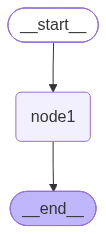

In [12]:
Image(compiled_graph.get_graph().draw_mermaid_png())

In [13]:
result = compiled_graph.invoke({
    "att1": "Original Value",
    "att2": "Hello"
})

In [14]:
print(result)

{'att1': 'Value Changed by node some_function()', 'att2': 'Hello'}


In [16]:
result = compiled_graph.invoke({
    "att1": "HOW ARE YOU",
    "att2": "HEY"
})

In [17]:
print(result)

{'att1': 'Value Changed by node some_function()', 'att2': 'HEY'}


# MULTI NODE EXAMPLE

In [18]:
class State(TypedDict):
    graph_state: str

In [19]:
def first_node(state):
    print("This is my first node")
    return {"graph_state": state['graph_state'] + "Hi, I am traveling "}

def second_node(state):
    print("This is my second node")
    return {"graph_state": state['graph_state'] + "United Kigdom - London"}

def third_node(state):
    print("This is my third node")
    return {"graph_state": state['graph_state'] + "United State of America (USA)"}

In [21]:
# Logic
import random
from typing import Literal

def decide_location(state) -> Literal["second_node", "third_node"]:
    graph_state = state['graph_state']
    if random.random() < 0.5:
        return "second_node"
    else:
        return "third_node"

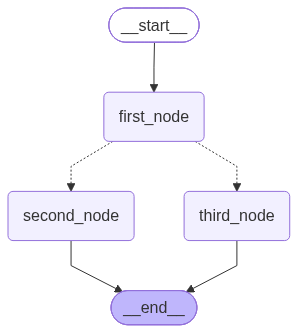

In [22]:
# Building LangGraph Model (connect with node, edge and end)

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(State)
builder.add_node("first_node", first_node)
builder.add_node("second_node", second_node)
builder.add_node("third_node", third_node)

builder.add_edge(START, 'first_node')
builder.add_conditional_edges("first_node", decide_location)
builder.add_edge("second_node", END)
builder.add_edge("third_node", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
graph.invoke({"graph_state": "Hi, Iam Batman, "})

This is my first node
This is my second node


{'graph_state': 'Hi, Iam Batman, Hi, I am traveling United Kigdom - London'}

In [24]:
graph.invoke({"graph_state": "Hi, Iam superman, "})

This is my first node
This is my second node


{'graph_state': 'Hi, Iam superman, Hi, I am traveling United Kigdom - London'}

In [25]:
graph.invoke({"graph_state": "Hi, Iam donald trump, "})

This is my first node
This is my second node


{'graph_state': 'Hi, Iam donald trump, Hi, I am traveling United Kigdom - London'}

In [27]:
graph.invoke({"graph_state": "Hi, my name is  amitabh bachan, "})

This is my first node
This is my second node


{'graph_state': 'Hi, my name is  amitabh bachan, Hi, I am traveling United Kigdom - London'}

#LANGGRAPHS USING TOOLS


In [28]:
!pip install --upgrade langchain langchain-community langgraph openai langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.0/147.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.4/94.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.1/565.1 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: httpcore2
    Found existing

In [1]:
from langgraph.graph import StateGraph, START
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import MessagesState
from IPython.display import Image, display
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from typing import Annotated
from typing_extensions import TypedDict


In [2]:
class State(TypedDict):
  messages: Annotated[list, add_messages]

In [3]:
!pip install duckduckgo-search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 26.8 MB/s eta 0:00:00


In [4]:
from langchain_community.tools import DuckDuckGoSearchResults, DuckDuckGoSearchRun

/tmp/ipykernel_21043/2978026465.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchResults, DuckDuckGoSearchRun


In [5]:
!pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 4.7 MB/s eta 0:00:00


In [6]:
search = DuckDuckGoSearchResults()
search.invoke("Obama's first name?")

'snippet: 2 days ago - Obama was also a member of the ... a self-named group of friends who spent time together and smoked marijuana. After graduating from high school in 1979, Obama moved to Los Angeles to attend Occidental College on a full scholarship. In February 1981, Obama made his first public speech, ..., title: Barack Obama - Wikipedia, link: https://en.wikipedia.org/wiki/Barack_Obama, snippet: July 9, 2026 - Obama is a surname. It most commonly refers to Barack Obama (born 1961), the 44th president of the United States. Obama is a common Fang masculine name in western Central Africa., title: Obama (surname) - Wikipedia, link: https://en.wikipedia.org/wiki/Obama_(surname), snippet: 1 week ago - Barack Hussein Obama II was born on August 4, 1961 in Kapiʻolani Medical Center for Women and Children (called Kapiʻolani Maternity & Gynecological Hospital in 1961) in Honolulu, Hawaii. He is the first President to have been born in Hawaii. His father was a black exchange student from 

In [7]:
search.invoke("who is Narendra Modi?")

'snippet: 16 hours ago - Narendra Damodardas Modi (born 17 September 1950) is an Indian politician who has served as the prime minister of India since 26 May 2014. Modi was the chief minister of Gujarat from 2001 to 2014 and is the Member of Parliament (MP) for Varanasi. He is a member of the Bharatiya Janata Party ..., title: Narendra Modi - Wikipedia, link: https://en.wikipedia.org/wiki/Narendra_Modi, snippet: 3 weeks ago - Narendra Damodardas Modi (born: 17 September, 1950) is an Indian politician who is the 14th and current Prime Minister of the Republic of India since 2014. He was previously the Chief Minister of the state of Gujarat from 2001 to 2014. He was later elected as the prime minister in May 2014., title: Narendra Modi - Simple English Wikipedia, the free encyclopedia, link: https://simple.wikipedia.org/wiki/Narendra_Modi, snippet: 4 days ago - The timing of raids on the opposition leaders is often made to coincide with elections or other political consequences. Accordin

In [8]:
from langchain_community.tools import DuckDuckGoSearchRun

def search_duckduckgo(query: str):
  search = DuckDuckGoSearchRun()
  return search.invoke(query)

  # created a function to run the query

In [9]:
result = search_duckduckgo("What are AI agent?")
print(result)

20 hours ago - Layer 6: Security and compliance – a protective framework for safe operation and compliance with regulatory boundaries. At this layer, security and compliance features embedded into all the AI agent stack layers are integrated together. 3 days ago - In evolutionary systems, a "fitness function" determines which agents are more likely to reproduce. This is analogous to natural selection, where organisms evolve to maximize their chances of survival and reproduction. Some AI systems, such as nearest-neighbor, reason by analogy rather than ... 3 days ago - An artificial intelligence (AI) agent refers to a system or program that is capable of autonomously performing tasks on behalf of a user or another system. April 2, 2026 - AI agents are software systems that use AI to pursue goals and complete tasks on behalf of users. Learn more with Google Cloud. 5 days ago - What is AI agents how and why businesses use AI agents, and how to use AI agents with AWS.


In [10]:
result = search_duckduckgo("WHAT IS MACHINE LEARNING ?")
print(result)

1 week ago - Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. 3 days ago - The central premise of machine learning (ML) is that if you optimize a model’s performance on a dataset of tasks that adequately resemble the real-world problems it will be used for—through a process called model training—the model can make accurate predictions on the new data it sees in its ultimate use case. January 27, 2026 - Machine learning (ML) is a way to train software, called a model, to make predictions or generate content using data. March 4, 2026 - When companies today deploy artificial ... ambiguously. Machine learning is a subfield of artificial intelligence that gives computers the ability to learn without explicitly being programmed.... March 19, 2026 - With machine learning, computers teach thems

In [11]:
from langchain_openai import ChatOpenAI
from getpass import getpass
OPENAI_API_KEY = getpass("Enter your API key here :")

Enter your API key here :··········


In [12]:
import os
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

In [13]:
llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)

In [14]:
llm.invoke("Hello").content

'Hello! How can I assist you today?'

In [21]:
def add(a: int, b: int) -> int:
  "add a and b"
  return a + b

def multiply(a: int, b: int) -> int:
  "multiply a and b"
  return a * b

In [22]:
tools = [search_duckduckgo, add, multiply]
llm_with_tools = llm.bind_tools(tools)

In [23]:
def chatbot(state: State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [24]:
from langgraph.prebuilt import ToolNode, tools_condition

In [26]:
def search_duckduckgo(query: str):
  """Searches DuckDuckGo for the given query.""" # Added docstring here
  search = DuckDuckGoSearchRun()
  return search.invoke(query)

def add(a: int, b: int) -> int:
  """Adds a and b"""
  return a + b

def multiply(a: int, b: int) -> int:
  """Multiply a and b"""
  return a * b

tools = [search_duckduckgo, add, multiply]
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

from langgraph.prebuilt import ToolNode, tools_condition

graph_builder = StateGraph(State)

graph_builder.add_node("assistant", chatbot)
graph_builder.add_node("tools", ToolNode(tools))

# Start the graph with the assistant (LLM)
graph_builder.add_edge(START, "assistant")

# Check the LLM response:
# If a tool is requested → go to "tools"
# If no tool is requested → END

graph_builder.add_conditional_edges("assistant", tools_condition)
# After the tool executes, send the result back to the assistant
# so the LLM can generate the final answer
graph_builder.add_edge("tools", "assistant")

react_graph = graph_builder.compile()

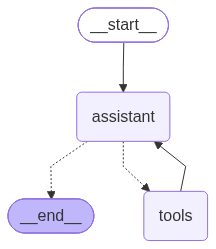

In [27]:
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [28]:
response = react_graph.invoke({"messages":[HumanMessage(content="What is the weather in Bangalore. Multiply it by 2 and add 5.")]})

In [29]:
print(response['messages'])

[HumanMessage(content='What is the weather in Bangalore. Multiply it by 2 and add 5.', additional_kwargs={}, response_metadata={}, id='9c481437-6204-4daf-a8b9-9733cd7ea637'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 110, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3817d51ca9', 'id': 'chatcmpl-ECSjGVELRSQYrB8kff9fGCKAg06rd', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ffbfc-ce02-7ee0-a524-66a290283fb2-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'current weather in Bangalore'}, 'id': 'call_DoNLxncDajeHQdwmWcBWvQLr', 'type': 'too

In [30]:
response['messages']

[HumanMessage(content='What is the weather in Bangalore. Multiply it by 2 and add 5.', additional_kwargs={}, response_metadata={}, id='9c481437-6204-4daf-a8b9-9733cd7ea637'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 110, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3817d51ca9', 'id': 'chatcmpl-ECSjGVELRSQYrB8kff9fGCKAg06rd', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ffbfc-ce02-7ee0-a524-66a290283fb2-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'current weather in Bangalore'}, 'id': 'call_DoNLxncDajeHQdwmWcBWvQLr', 'type': 'to

In [31]:
response = react_graph.invoke({"messages":[HumanMessage(content=" Multiply 8  by 2.")]})

In [32]:
print(response['messages'])

[HumanMessage(content=' Multiply 8  by 2.', additional_kwargs={}, response_metadata={}, id='40fe1b61-0241-4de4-996c-ed60f648f69e'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 101, 'total_tokens': 118, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3817d51ca9', 'id': 'chatcmpl-ECSoIJYWwZuFLYcTj3EqZGiCQby58', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ffc01-9690-7942-8531-8c3d311ce305-0', tool_calls=[{'name': 'multiply', 'args': {'a': 8, 'b': 2}, 'id': 'call_SdFWP9pvdsiWHOHMVoZtFjpf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 101, 'outpu

In [33]:
response['messages']

[HumanMessage(content=' Multiply 8  by 2.', additional_kwargs={}, response_metadata={}, id='40fe1b61-0241-4de4-996c-ed60f648f69e'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 101, 'total_tokens': 118, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3817d51ca9', 'id': 'chatcmpl-ECSoIJYWwZuFLYcTj3EqZGiCQby58', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ffc01-9690-7942-8531-8c3d311ce305-0', tool_calls=[{'name': 'multiply', 'args': {'a': 8, 'b': 2}, 'id': 'call_SdFWP9pvdsiWHOHMVoZtFjpf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 101, 'outp